# 8주차 : LSTM 모델 완성 및 벤치마크 모델과의 비교

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import random


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [3]:
file_path = './processed_sequences/train_data_seq_30d.csv' 
df = pd.read_csv(file_path)

seq_length = 30
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]
unique_splits = sorted(df['split_id'].unique())

## LSTM 셀 만들기

LSTM의 CELL 정의  
- 이니셜라이즈
- 순전파 기능

**이니셜라이즈**  
nn.Linear 수학적으로 행렬을 곱하고 편향을 더해주는 $y=Wx+b$ 를 수행할수 있는 층
| 변수명 | 역할 | 의미 및 기능 |
|---|---|---|
| W_f | Fprget gate | 무얼 잊을지 |
| W_i | Input gate | 입력 가중치 |
| W_s_tidle | Candidate values | 새로운 기억 후보 |
| W_o | Output gate | 출력 가중치 |

**순전파**  

과거의 기억(h_prev, s_prev)과 현재의 입력(x_t)을 받아, 4개의 게이트를 거치며 불필요한 기억은 지우고, 새로운 정보를 더해 오늘 갱신된 장기 기억(s_t)과 단기 출력(h_t)을 만들어 다음 단계로 넘겨주는 핵심 실행 함수

| 변수명 | 역할 | 의미 및 기능 | 계산 방식 |
|---|---|---|---|
| h_prev, s_prev | Previous States | 직전 시점에서 넘어온 단기 은닉 상태(h)와 장기 셀 상태(s) | hidden_state 튜플 분해 |
| combined | Input 병합 | 오늘의 입력값(x_t)과 과거의 정보(h_prev)를 하나로 이어붙인 데이터 | torch.cat |
| f_t | Forget Gate | 어제의 장기 기억 중 얼마나 잊어버릴지(0~1 비율) 결정 | sigmoid 적용 |
| i_t | Input Gate | 오늘의 새로운 정보 중 얼마나 반영할지(0~1 비율) 결정 | sigmoid 적용 |
| s_tilde_t | Candidate Values | 기억에 새롭게 더해질 수 있는 정보의 본체 | tanh 적용 |
| s_t | Cell State | 과거 기억을 지우고 새로운 정보를 더해 오늘의 최종 장기 기억 생성 | 덧셈 및 아다마르 곱 |
| o_t | Output Gate | 갱신된 장기 기억 중 밖으로 얼마나 내보낼지(0~1 비율) 결정 | sigmoid 적용 |
| h_t | Hidden State | 장기 기억(s_t)을 한 번 더 압축(tanh)한 뒤 출력 비율(o_t)을 곱해 최종 결과물 생성 | 아다마르 곱 |

In [4]:
import torch
import torch.nn as nn

class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_s_tilde = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x_t, hidden_state):
        h_prev, s_prev = hidden_state
        
        combined = torch.cat((x_t, h_prev), dim=1)
        
        f_t = torch.sigmoid(self.W_f(combined))
        i_t = torch.sigmoid(self.W_i(combined))
        s_tilde_t = torch.tanh(self.W_s_tilde(combined))
        s_t = f_t * s_prev + i_t * s_tilde_t
        o_t = torch.sigmoid(self.W_o(combined))
        h_t = o_t * torch.tanh(s_t)
        
        return h_t, s_t

**이니셜라이즈 (__init__)**

앞서 만든 LSTM 셀을 주로 삼고, 과적합 방지 장치 Dropout 와 최종 판단을 내릴 출력층을 조립하는 전체 모델의 준비 단계

| 변수명 | 역할 | 의미 및 기능 |
|---|---|---|
| hidden_size | 기억 용량 설정 | LSTM 내부에서 정보를 담아둘 뉴런의 개수(기억의 크기)를 지정 |
| lstm_cell | LSTM 핵심 부품 장착 | 앞서 직접 설계한 `LSTMCell`을 가져와 데이터가 통과할 메인 파이프로 설정 |
| dropout | 과적합 방지 층 (Dropout) | 학습 중 은닉 상태의 일부(10%)를 무작위로 가려서, 모델이 꼼수를 쓰지 못하게 방해함 |
| fc | 최종 출력층 (Fully Connected) | LSTM을 통과해 나온 최종 기억을 바탕으로 주가가 오를지(1) 내릴지(0) 2개의 결과값으로 변환 |


**포워드 (forward)**

30일 치의 전체 데이터를 받아 첫날부터 마지막 날까지 하루씩 쪼개 LSTM 셀에 순차적으로 통과시키고, 마지막 날의 최종 기억을 바탕으로 최종 예측값을 도출하는 전체 실행 흐름

| 변수명 / 단계 | 역할 | 의미 및 기능 |
|---|---|---|
| batch_size, seq_length | 데이터 규격 파악 | 입력된 3차원 데이터에서 한 번에 풀 문제의 개수(배치)와 날짜 길이(30일)를 추출 |
| h_t, s_t | 초기 상태 (0일 차) 세팅 | 첫째 날(t=0) 계산을 위해 단기 은닉 상태(h)와 장기 셀 상태(s)를 0으로 채운 빈 텐서 생성 |
| for t in range(seq_length) | 시간의 흐름 (Time steps) | 1일 차부터 30일 차까지 하루 단위로 시간을 흐르게 하는 반복문 시작 |
| x_t | 일별 데이터 추출 | 전체 30일 치 3차원 데이터 중 t번째 날의 데이터만 얇게 썰어내어(2차원) 가져옴 |
| self.lstm_cell(...) | 하루 치 연산 실행 | 오늘 데이터(x_t)와 어제 기억(h_t, s_t)을 넣고, 오늘 새롭게 갱신된 기억들을 반환받음 |
| out = self.dropout(h_t) | 드롭아웃 적용 | 30일의 연산이 모두 끝난 뒤 나온 **가장 마지막 날의 최종 은닉 상태**에 과적합 방지 적용 |
| out = self.fc(out) | 최종 예측 수행 | 드롭아웃을 거친 최종 기억을 출력층에 넣어 2개의 최종 클래스(아웃퍼폼/언더퍼폼) 확률값으로 변환 |

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, output_size=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        
        self.lstm_cell = LSTMCell(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)
        seq_length = x.size(1)
        
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        s_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        for t in range(seq_length):
            x_t = x[:, t, :] 
            h_t, s_t = self.lstm_cell(x_t, (h_t, s_t))
            
        out = self.dropout(h_t)
        out = self.fc(out)
        
        return out

model = LSTMModel(input_size=1, hidden_size=25, output_size=2)
print("모델 구조:\n", model)

모델 구조:
 LSTMModel(
  (lstm_cell): LSTMCell(
    (W_f): Linear(in_features=26, out_features=25, bias=True)
    (W_i): Linear(in_features=26, out_features=25, bias=True)
    (W_s_tilde): Linear(in_features=26, out_features=25, bias=True)
    (W_o): Linear(in_features=26, out_features=25, bias=True)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=25, out_features=2, bias=True)
)


LSTM split별로 각각 10번씩 돌려서 LSTM성능확인

In [6]:
batch_size = 256
num_epochs = 10 
lstm_acc_list = []

for split_id in unique_splits:
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    X_train_tensor = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train_tensor = torch.tensor(train_df['target'].values, dtype=torch.long)
    X_test_tensor = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_test_tensor = torch.tensor(test_df['target'].values, dtype=torch.long)
    
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)
    
    model = LSTMModel(input_size=1, hidden_size=25, output_size=2)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            _, predicted = torch.max(model(batch_X).data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
    split_acc = 100 * correct / total
    lstm_acc_list.append(split_acc)
    print(f"Split {split_id} | LSTM: {split_acc:.2f}%")

print(f"\nLSTM Accuracy: {np.mean(lstm_acc_list):.2f}%")

Split 1 | LSTM: 61.43%
Split 2 | LSTM: 61.12%
Split 3 | LSTM: 61.00%
Split 4 | LSTM: 60.43%
Split 5 | LSTM: 61.18%
Split 6 | LSTM: 61.12%
Split 7 | LSTM: 61.73%
Split 8 | LSTM: 62.04%
Split 9 | LSTM: 62.24%

LSTM Accuracy: 61.37%


## 벤치마크 모델

LOG

In [7]:
log_acc_list = []

for split_id in unique_splits:
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    X_train = train_df[feature_cols].values
    y_train = train_df['target'].values
    X_test = test_df[feature_cols].values
    y_test = test_df['target'].values
    
    log_model = LogisticRegression(random_state=42, max_iter=1000)
    log_model.fit(X_train, y_train)
    log_acc = accuracy_score(y_test, log_model.predict(X_test)) * 100
    log_acc_list.append(log_acc)
    
    print(f"Split {split_id} | LOG: {log_acc:.2f}%")

print(f"\nLOG Accuracy: {np.mean(log_acc_list):.2f}%")

Split 1 | LOG: 61.37%
Split 2 | LOG: 62.09%
Split 3 | LOG: 61.58%
Split 4 | LOG: 61.88%
Split 5 | LOG: 61.51%
Split 6 | LOG: 61.89%
Split 7 | LOG: 61.46%
Split 8 | LOG: 61.64%
Split 9 | LOG: 62.20%

LOG Accuracy: 61.74%


DNN

In [8]:
dnn_acc_list = []

for split_id in unique_splits:
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    X_train = train_df[feature_cols].values
    y_train = train_df['target'].values
    X_test = test_df[feature_cols].values
    y_test = test_df['target'].values
    
    dnn_model = MLPClassifier(hidden_layer_sizes=(25,), random_state=42, max_iter=1000)
    dnn_model.fit(X_train, y_train)
    dnn_acc = accuracy_score(y_test, dnn_model.predict(X_test)) * 100
    dnn_acc_list.append(dnn_acc)
    
    print(f"Split {split_id} | DNN: {dnn_acc:.2f}%")

print(f"\nDNN Accuracy: {np.mean(dnn_acc_list):.2f}%")

Split 1 | DNN: 60.48%
Split 2 | DNN: 61.74%
Split 3 | DNN: 60.28%
Split 4 | DNN: 60.95%
Split 5 | DNN: 61.40%
Split 6 | DNN: 60.56%
Split 7 | DNN: 60.16%
Split 8 | DNN: 62.12%
Split 9 | DNN: 61.41%

DNN Accuracy: 61.01%


RAF

In [9]:
rf_acc_list = []

for split_id in unique_splits:
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    X_train = train_df[feature_cols].values
    y_train = train_df['target'].values
    X_test = test_df[feature_cols].values
    y_test = test_df['target'].values
    
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_acc = accuracy_score(y_test, rf_model.predict(X_test)) * 100
    rf_acc_list.append(rf_acc)
    
    print(f"Split {split_id} | RAF: {rf_acc:.2f}%")

print(f"\nRAF Accuracy: {np.mean(rf_acc_list):.2f}%")

Split 1 | RAF: 62.43%
Split 2 | RAF: 61.55%
Split 3 | RAF: 60.71%
Split 4 | RAF: 60.94%
Split 5 | RAF: 61.00%
Split 6 | RAF: 61.15%
Split 7 | RAF: 61.15%
Split 8 | RAF: 60.30%
Split 9 | RAF: 61.91%

RAF Accuracy: 61.24%


10번의 에포크 기준  
LSTM Accuracy: 61.37%  
LOG Accuracy: 61.74%  
DNN Accuracy: 61.01%  
RAF Accuracy: 61.24%  
  
LSTM이 미세하게 나마 DNN, RAF을 상회하는 모습 발견  

평균적으로 LOG가 살짝 우세하게 나왔으나  
스플릿별 정확도 최고값은 LSTM: 62.24%, LOG: 62.20%으로 LSTM 이 LOG보다 미세하게 높음

## 최적의 에포크를 찾기 위해서 시각화

[Split 1] 에포크별 성능 (150 Epochs)
Epoch [1/150] | Train Loss: 0.6668 | Val Loss: 0.6677
Epoch [10/150] | Train Loss: 0.6279 | Val Loss: 0.6240
Epoch [20/150] | Train Loss: 0.6053 | Val Loss: 0.5995
Epoch [30/150] | Train Loss: 0.5803 | Val Loss: 0.5695
Epoch [40/150] | Train Loss: 0.5664 | Val Loss: 0.5580
Epoch [50/150] | Train Loss: 0.5578 | Val Loss: 0.5527
Epoch [60/150] | Train Loss: 0.5528 | Val Loss: 0.5507
Epoch [70/150] | Train Loss: 0.5504 | Val Loss: 0.5539
Epoch [80/150] | Train Loss: 0.5485 | Val Loss: 0.5506
Epoch [90/150] | Train Loss: 0.5457 | Val Loss: 0.5483
Epoch [100/150] | Train Loss: 0.5455 | Val Loss: 0.5470
Epoch [110/150] | Train Loss: 0.5429 | Val Loss: 0.5526
Epoch [120/150] | Train Loss: 0.5442 | Val Loss: 0.5511
Epoch [130/150] | Train Loss: 0.5427 | Val Loss: 0.5507
Epoch [140/150] | Train Loss: 0.5410 | Val Loss: 0.5509
Epoch [150/150] | Train Loss: 0.5404 | Val Loss: 0.5556


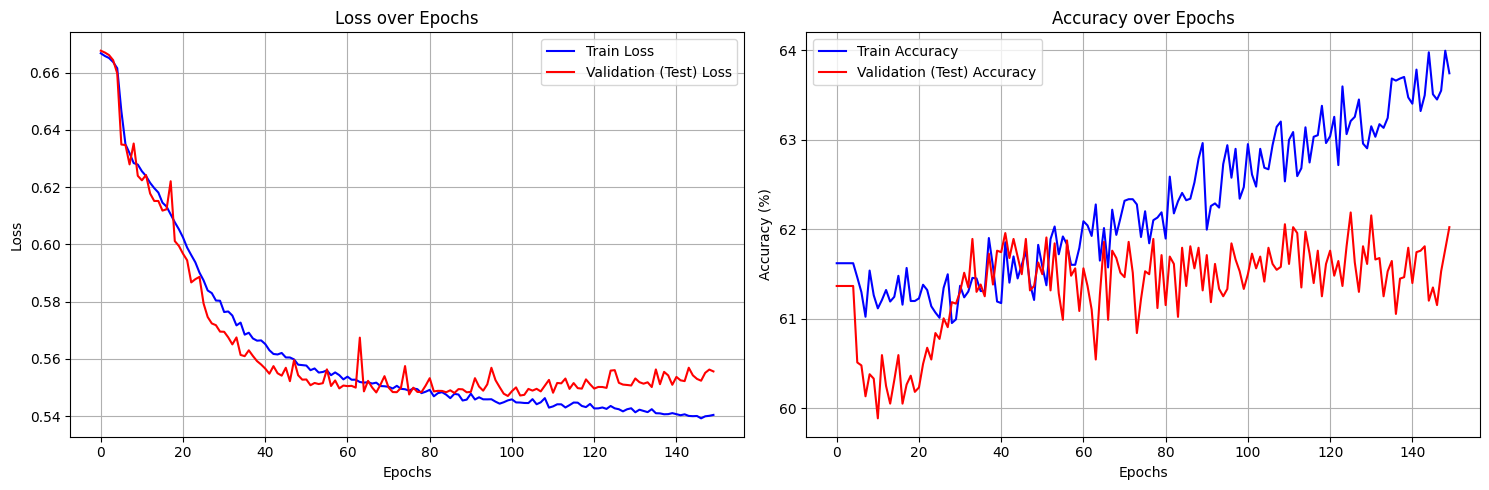

In [13]:
import matplotlib.pyplot as plt

target_split = 1
explore_epochs = 150 

split_df = df[df['split_id'] == target_split]
train_df = split_df[split_df['dataset_type'] == 'Train']
test_df = split_df[split_df['dataset_type'] == 'Test']

X_train_tensor = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
y_train_tensor = torch.tensor(train_df['target'].values, dtype=torch.long)
X_test_tensor = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(test_df['target'].values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256, shuffle=False)

model = LSTMModel(input_size=1, hidden_size=25, output_size=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"[Split {target_split}] 에포크별 성능 ({explore_epochs} Epochs)")

for epoch in range(explore_epochs):
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()
        
    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)
    
    model.eval()
    running_val_loss = 0.0
    correct_val, total_val = 0, 0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            
    avg_val_loss = running_val_loss / len(test_loader)
    val_acc = 100 * correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{explore_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Validation (Test) Loss', color='red')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label='Train Accuracy', color='blue')
axes[1].plot(val_accs, label='Validation (Test) Accuracy', color='red')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

40 정도가 제일 적절할 것 같음

In [14]:
batch_size = 256
num_epochs = 40
lstm_acc_list = []

for split_id in unique_splits:
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    X_train_tensor = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train_tensor = torch.tensor(train_df['target'].values, dtype=torch.long)
    X_test_tensor = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_test_tensor = torch.tensor(test_df['target'].values, dtype=torch.long)
    
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)
    
    model = LSTMModel(input_size=1, hidden_size=25, output_size=2)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            _, predicted = torch.max(model(batch_X).data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
    split_acc = 100 * correct / total
    lstm_acc_list.append(split_acc)
    print(f"Split {split_id} | LSTM: {split_acc:.2f}%")

print(f"\nLSTM Accuracy: {np.mean(lstm_acc_list):.2f}%")

Split 1 | LSTM: 61.30%
Split 2 | LSTM: 60.87%
Split 3 | LSTM: 61.60%
Split 4 | LSTM: 61.15%
Split 5 | LSTM: 60.41%
Split 6 | LSTM: 60.87%
Split 7 | LSTM: 61.64%
Split 8 | LSTM: 61.71%
Split 9 | LSTM: 60.58%

LSTM Accuracy: 61.13%
